# Gene Signature Scoring & Clustering

Ce notebook extrait les signatures géniques du réseau de régulation (figure Semrau),
calcule un score par cellule pour chaque signature, puis clusterise les cellules
en fonction du score dominant.

**Signatures (extraites de l'image du réseau) :**
| Couleur | Type cellulaire |
|---------|----------------|
| Bleu | Pluripotency |
| Violet | Post-implantation Epiblast |
| Orange | Extraembryonic Endoderm |
| Marron | Neuroectoderm |

## 1. Imports & Configuration

In [36]:
import os
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import zscore

sc.settings.verbosity = 2
sc.settings.set_figure_params(dpi=100, figsize=(8, 6), facecolor='white')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

## 2. Signatures géniques (extraites du réseau)

Les signatures ont été extraites manuellement à partir du réseau de régulation de la figure.
Chaque couleur correspond à un type cellulaire distinct.

In [37]:
# ─────────────────────────────────────────────────────────────────
# SIGNATURES GÉNIQUES — extraites du réseau (image PNG)
# ─────────────────────────────────────────────────────────────────

SIGNATURES = {
    "Pluripotency": [
        "Esrrb", "Nr0b1", "Dppa3", "Pou5f1", "Sox2",
        "Jarid2", "Zfp42", "Klf4", "Fgf4", "Klf2"
    ],
    "Post-implantation_Epiblast": [
        "Dppa2", "Dnmt3a", "Dnmt3b", "Zic2", "Zic3",
        "Cer1", "Fgf5", "Wnt8a", "Dppa4", "Pou3f1"
    ],
    "Extraembryonic_Endoderm": [
        "Fst", "Pdgfra", "Gata4", "Gata6", "Col4a2",
        "Krt8", "Sox17", "Lamb1", "Dab2", "Sparc"
    ],
    "Neuroectoderm": [
        "Sox1", "Sox11", "Meis1", "Nes", "Ascl1",
        "Pax6", "Sox9", "Cd24a", "Cdh2", "Hoxb2", "Hoxa1"
    ]
}

# Palette de couleurs cohérente avec la figure originale
PALETTE = {
    "Pluripotency":               "#4472C4",  # bleu
    "Post-implantation_Epiblast": "#7030A0",  # violet
    "Extraembryonic_Endoderm":    "#ED7D31",  # orange
    "Neuroectoderm":              "#843C0C",  # marron
    "Ambiguous":                  "#AAAAAA",  # gris pour cellules non assignées
}

# Affichage récapitulatif
print("Signatures géniques chargées :")
for sig_name, genes in SIGNATURES.items():
    print(f"  {sig_name:35s} → {len(genes)} gènes : {', '.join(genes)}")

Signatures géniques chargées :
  Pluripotency                        → 10 gènes : Esrrb, Nr0b1, Dppa3, Pou5f1, Sox2, Jarid2, Zfp42, Klf4, Fgf4, Klf2
  Post-implantation_Epiblast          → 10 gènes : Dppa2, Dnmt3a, Dnmt3b, Zic2, Zic3, Cer1, Fgf5, Wnt8a, Dppa4, Pou3f1
  Extraembryonic_Endoderm             → 10 gènes : Fst, Pdgfra, Gata4, Gata6, Col4a2, Krt8, Sox17, Lamb1, Dab2, Sparc
  Neuroectoderm                       → 11 gènes : Sox1, Sox11, Meis1, Nes, Ascl1, Pax6, Sox9, Cd24a, Cdh2, Hoxb2, Hoxa1


## 3. Chargement des données

In [38]:
data_path = os.path.join('Data', 'data.h5ad')
adata = ad.read_h5ad(data_path)

print(f"AnnData chargé : {adata.shape[0]} cellules × {adata.shape[1]} gènes")
print(f"Métadonnées disponibles (obs) : {list(adata.obs.columns)}")
print(f"Couche(s) disponible(s)       : {list(adata.layers.keys()) if adata.layers else 'aucune (X utilisé)'}")
adata

AnnData chargé : 2449 cellules × 41 gènes
Métadonnées disponibles (obs) : ['time']
Couche(s) disponible(s)       : aucune (X utilisé)


AnnData object with n_obs × n_vars = 2449 × 41
    obs: 'time'
    var: 'd0', 'd1'

## 4. Contrôle qualité — gènes de la signature présents dans le dataset

In [39]:
# Noms des gènes dans l'AnnData (var_names ou var index)
gene_names = list(adata.var_names)

print("Couverture des signatures dans le dataset :")
print("-" * 60)

available_signatures = {}
for sig_name, genes in SIGNATURES.items():
    found    = [g for g in genes if g in gene_names]
    missing  = [g for g in genes if g not in gene_names]
    coverage = len(found) / len(genes) * 100
    available_signatures[sig_name] = found

    print(f"\n{sig_name}")
    print(f"  Trouvés  ({len(found):2d}/{len(genes)}) : {', '.join(found) if found else 'aucun'}")
    if missing:
        print(f"  Absents  ({len(missing):2d}/{len(genes)}) : {', '.join(missing)}")
    print(f"  Couverture : {coverage:.0f}%")

print("\n" + "-" * 60)
print("Signatures disponibles pour le scoring :", list(available_signatures.keys()))

Couverture des signatures dans le dataset :
------------------------------------------------------------

Pluripotency
  Trouvés  (10/10) : Esrrb, Nr0b1, Dppa3, Pou5f1, Sox2, Jarid2, Zfp42, Klf4, Fgf4, Klf2
  Couverture : 100%

Post-implantation_Epiblast
  Trouvés  (10/10) : Dppa2, Dnmt3a, Dnmt3b, Zic2, Zic3, Cer1, Fgf5, Wnt8a, Dppa4, Pou3f1
  Couverture : 100%

Extraembryonic_Endoderm
  Trouvés  (10/10) : Fst, Pdgfra, Gata4, Gata6, Col4a2, Krt8, Sox17, Lamb1, Dab2, Sparc
  Couverture : 100%

Neuroectoderm
  Trouvés  (11/11) : Sox1, Sox11, Meis1, Nes, Ascl1, Pax6, Sox9, Cd24a, Cdh2, Hoxb2, Hoxa1
  Couverture : 100%

------------------------------------------------------------
Signatures disponibles pour le scoring : ['Pluripotency', 'Post-implantation_Epiblast', 'Extraembryonic_Endoderm', 'Neuroectoderm']


## 5. Préprocessing (si nécessaire)

In [40]:
# Vérification : l'expression est-elle déjà normalisée ?
print("Min / Max de X :", adata.X.min(), "/", adata.X.max())

# ─── Normalisation & log-transformation (si X contient des counts bruts) ───
# Décommentez les lignes ci-dessous si X contient des counts bruts non normalisés.
#
sc.pp.normalize_total(adata, target_sum=1e4)  # CPM / 10k
sc.pp.log1p(adata)                            # log(1 + X)
#
# Si X contient déjà des valeurs log-normalisées → aucun préprocessing nécessaire.

print("Données prêtes pour le scoring.")

Min / Max de X : 0 / 95
normalizing counts per cell
    finished (0:00:00)
Données prêtes pour le scoring.


/opt/homebrew/Caskroom/miniconda/base/envs/cardamom_light/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)


## 6. Calcul des scores de signature

Deux méthodes sont proposées :
- **`sc.tl.score_genes`** (Seurat-style, recommandée)
- **Moyenne des z-scores** (alternative robuste)

### 6.1 Méthode 1 — `sc.tl.score_genes` (Scanpy / Seurat style)

In [41]:
score_keys = []

for sig_name, genes in available_signatures.items():
    if not genes:
        print(f"[SKIP] {sig_name} — aucun gène disponible")
        continue

    score_key = f"score_{sig_name}"
    sc.tl.score_genes(
        adata,
        gene_list=genes,
        score_name=score_key,
        random_state=RANDOM_SEED,
        use_raw=False
    )
    score_keys.append(score_key)
    print(f"[OK] {sig_name:35s} → score stocké dans adata.obs['{score_key}']")

print(f"\n{len(score_keys)} score(s) calculé(s).")

computing score 'score_Pluripotency'
    finished (0:00:00)
[OK] Pluripotency                        → score stocké dans adata.obs['score_Pluripotency']
computing score 'score_Post-implantation_Epiblast'
    finished (0:00:00)
[OK] Post-implantation_Epiblast          → score stocké dans adata.obs['score_Post-implantation_Epiblast']
computing score 'score_Extraembryonic_Endoderm'
    finished (0:00:00)
[OK] Extraembryonic_Endoderm             → score stocké dans adata.obs['score_Extraembryonic_Endoderm']
computing score 'score_Neuroectoderm'
    finished (0:00:00)
[OK] Neuroectoderm                       → score stocké dans adata.obs['score_Neuroectoderm']

4 score(s) calculé(s).


### 6.2 Méthode 2 — Moyenne des z-scores (alternative)

In [42]:
def zscore_signature(adata, genes, score_name):
    """Calcule la moyenne des z-scores par gène sur l'ensemble des cellules."""
    genes_present = [g for g in genes if g in adata.var_names]
    if not genes_present:
        adata.obs[score_name] = 0.0
        return

    # Extraction de la sous-matrice (dense)
    expr = adata[:, genes_present].X
    if hasattr(expr, 'toarray'):
        expr = expr.toarray()

    # Z-score par gène (axe = cellules)
    z = zscore(expr, axis=0, nan_policy='omit')
    # Score = moyenne sur les gènes de la signature
    adata.obs[score_name] = np.nanmean(z, axis=1)


for sig_name, genes in available_signatures.items():
    zscore_signature(adata, genes, score_name=f"zscore_{sig_name}")
    print(f"[OK] zscore_{sig_name}")

print("\nScores z-score calculés et stockés dans adata.obs.")

[OK] zscore_Pluripotency
[OK] zscore_Post-implantation_Epiblast
[OK] zscore_Extraembryonic_Endoderm
[OK] zscore_Neuroectoderm

Scores z-score calculés et stockés dans adata.obs.


## 7. Attribution du type cellulaire dominant

In [43]:
# ─── Choisir la méthode à utiliser pour l'assignation ───
# 'scanpy'  → utilise les scores sc.tl.score_genes  (score_*)
# 'zscore'  → utilise les moyennes de z-scores      (zscore_*)
METHOD = 'scanpy'   # ← modifier ici si besoin

if METHOD == 'scanpy':
    prefix = 'score_'
else:
    prefix = 'zscore_'

sig_names = list(available_signatures.keys())
score_cols = [f"{prefix}{s}" for s in sig_names]

# Matrice des scores (cellules × signatures)
score_matrix = adata.obs[score_cols].values

# Seuil : le score max doit dépasser la moyenne + k*std pour être assigné
# Mettre THRESHOLD = None pour assigner toutes les cellules sans exception
THRESHOLD = None   # ou par ex. 0.0

dominant_idx = np.argmax(score_matrix, axis=1)
dominant_label = np.array(sig_names)[dominant_idx]

if THRESHOLD is not None:
    max_scores = score_matrix[np.arange(len(score_matrix)), dominant_idx]
    mean_scores = score_matrix.mean(axis=1)
    dominant_label[max_scores < mean_scores + THRESHOLD] = "Ambiguous"

adata.obs["dominant_signature"] = pd.Categorical(dominant_label)

# Distribution
counts = adata.obs["dominant_signature"].value_counts()
print("Distribution des types cellulaires assignés :")
print(counts)
print(f"\nTotal cellules : {len(adata)}")

Distribution des types cellulaires assignés :
dominant_signature
Pluripotency                  1095
Post-implantation_Epiblast     516
Neuroectoderm                  429
Extraembryonic_Endoderm        409
Name: count, dtype: int64

Total cellules : 2449


In [44]:
adata_celltype = ad.read_h5ad(data_path)
adata_celltype.obs["cell_type"] = adata.obs["dominant_signature"]
adata_celltype.write_h5ad(data_path)

## 8. Réduction de dimension & Visualisation

### 8.1 PCA + UMAP sur les 41 gènes de la signature

In [45]:
# Tous les gènes des signatures (présents dans le dataset)
all_sig_genes = sorted(set(
    g for genes in available_signatures.values() for g in genes
))
print(f"{len(all_sig_genes)} gènes de signature présents dans le dataset :")
print(all_sig_genes)

# Sous-AnnData limité aux gènes de signature
adata_sig = adata[:, all_sig_genes].copy()

# PCA
n_pcs = min(30, len(all_sig_genes) - 1, len(adata_sig) - 1)
sc.tl.pca(adata_sig, n_comps=n_pcs, random_state=RANDOM_SEED)

# Voisins
sc.pp.neighbors(adata_sig, n_neighbors=15, n_pcs=n_pcs, random_state=RANDOM_SEED)

# UMAP
sc.tl.umap(adata_sig, random_state=RANDOM_SEED)

# Transfert des embeddings vers l'AnnData principal
adata.obsm['X_pca_sig']  = adata_sig.obsm['X_pca']
adata.obsm['X_umap_sig'] = adata_sig.obsm['X_umap']
adata.obs['dominant_signature'] = adata_sig.obs.get(
    'dominant_signature', adata.obs['dominant_signature']
)

print("PCA + UMAP calculés sur les gènes de signature.")

41 gènes de signature présents dans le dataset :
['Ascl1', 'Cd24a', 'Cdh2', 'Cer1', 'Col4a2', 'Dab2', 'Dnmt3a', 'Dnmt3b', 'Dppa2', 'Dppa3', 'Dppa4', 'Esrrb', 'Fgf4', 'Fgf5', 'Fst', 'Gata4', 'Gata6', 'Hoxa1', 'Hoxb2', 'Jarid2', 'Klf2', 'Klf4', 'Krt8', 'Lamb1', 'Meis1', 'Nes', 'Nr0b1', 'Pax6', 'Pdgfra', 'Pou3f1', 'Pou5f1', 'Sox1', 'Sox11', 'Sox17', 'Sox2', 'Sox9', 'Sparc', 'Wnt8a', 'Zfp42', 'Zic2', 'Zic3']
computing PCA


    with n_comps=30
    finished (0:00:00)
computing neighbors
    using data matrix X directly
    finished (0:00:00)
computing UMAP
    finished (0:00:01)
PCA + UMAP calculés sur les gènes de signature.


### 8.2 UMAP coloré par signature dominante

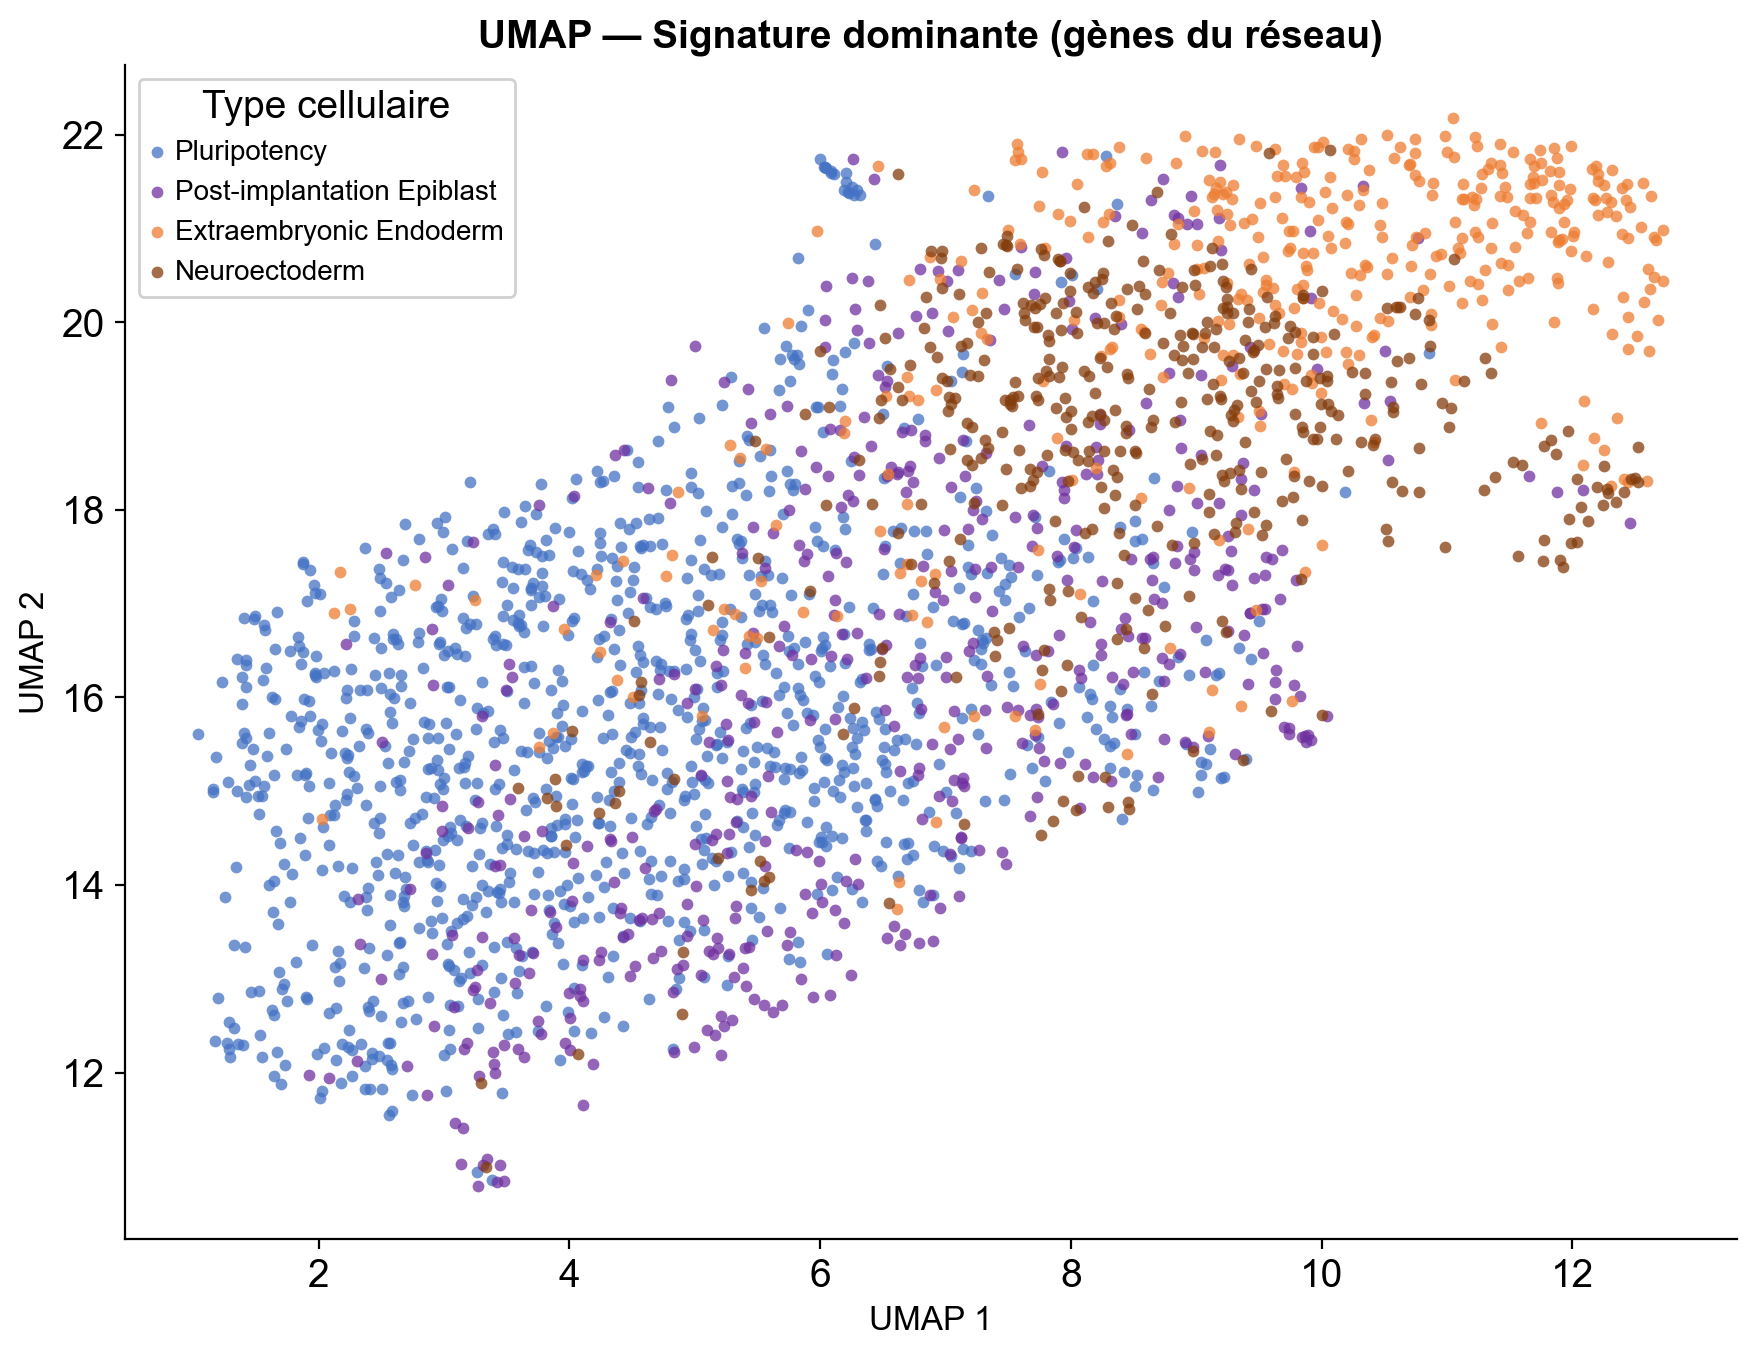

Figure sauvegardée : umap_dominant_signature.png


In [46]:
umap_coords = adata.obsm['X_umap_sig']
labels      = adata.obs['dominant_signature'].values
unique_labels = list(dict.fromkeys(labels))  # ordre de première apparition

fig, ax = plt.subplots(figsize=(9, 7))

for label in unique_labels:
    mask  = labels == label
    color = PALETTE.get(label, "#AAAAAA")
    ax.scatter(
        umap_coords[mask, 0],
        umap_coords[mask, 1],
        c=color, s=18, alpha=0.75, linewidths=0,
        label=label.replace("_", " ")
    )

ax.set_xlabel("UMAP 1", fontsize=12)
ax.set_ylabel("UMAP 2", fontsize=12)
ax.set_title("UMAP — Signature dominante (gènes du réseau)", fontsize=14, fontweight='bold')
ax.legend(title="Type cellulaire", framealpha=0.9, fontsize=10)
ax.grid(False)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()
print("Figure sauvegardée : umap_dominant_signature.png")

### 8.3 Heatmap des scores par type cellulaire assigné

/var/folders/lj/409601z9289fp_pv32k6f3frf4h14r/T/ipykernel_24993/3296517849.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_scores = score_df.groupby("Type")[score_df.columns[:-1].tolist()].mean()


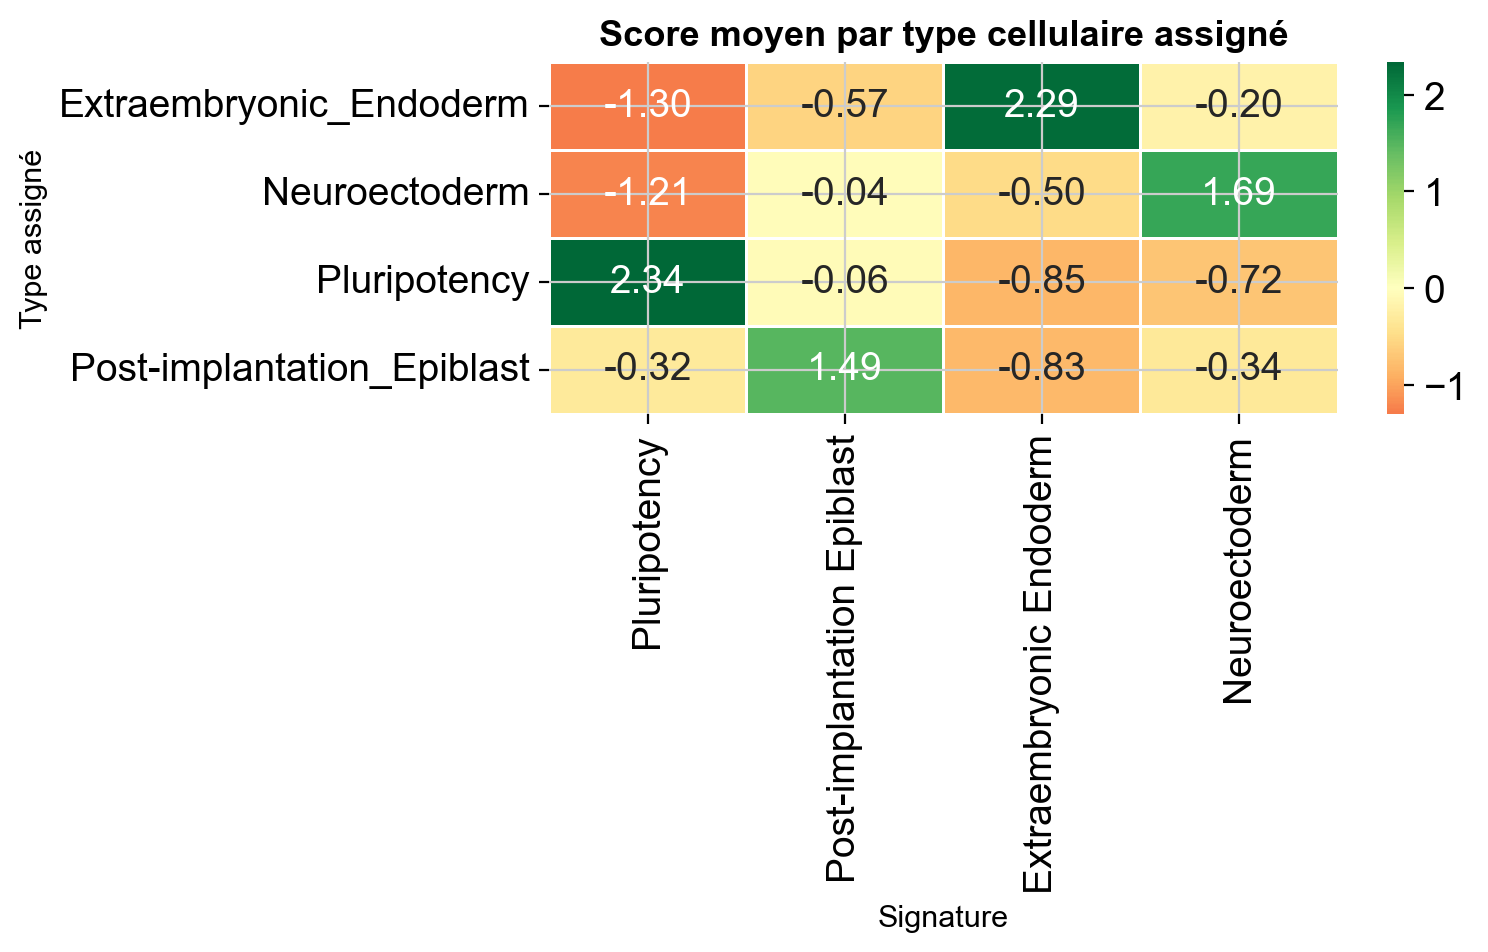

Figure sauvegardée : heatmap_scores.png


In [47]:
# Score moyen par groupe de cellules
score_df = adata.obs[score_cols + ["dominant_signature"]].copy()
score_df.columns = [c.replace(prefix, "").replace("_", " ") for c in score_cols] + ["Type"]

mean_scores = score_df.groupby("Type")[score_df.columns[:-1].tolist()].mean()

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    mean_scores,
    annot=True, fmt=".2f",
    cmap="RdYlGn", center=0,
    linewidths=0.5, ax=ax
)
ax.set_title("Score moyen par type cellulaire assigné", fontsize=13, fontweight='bold')
ax.set_xlabel("Signature", fontsize=11)
ax.set_ylabel("Type assigné", fontsize=11)
plt.tight_layout()
plt.show()
print("Figure sauvegardée : heatmap_scores.png")

### 8.4 Violin plots des scores

/var/folders/lj/409601z9289fp_pv32k6f3frf4h14r/T/ipykernel_24993/4117163130.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/lj/409601z9289fp_pv32k6f3frf4h14r/T/ipykernel_24993/4117163130.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/lj/409601z9289fp_pv32k6f3frf4h14r/T/ipykernel_24993/4117163130.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/lj/409601z9289fp_pv32k6f3frf4h14r/T/ipykernel_24993/4117163130.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is dep

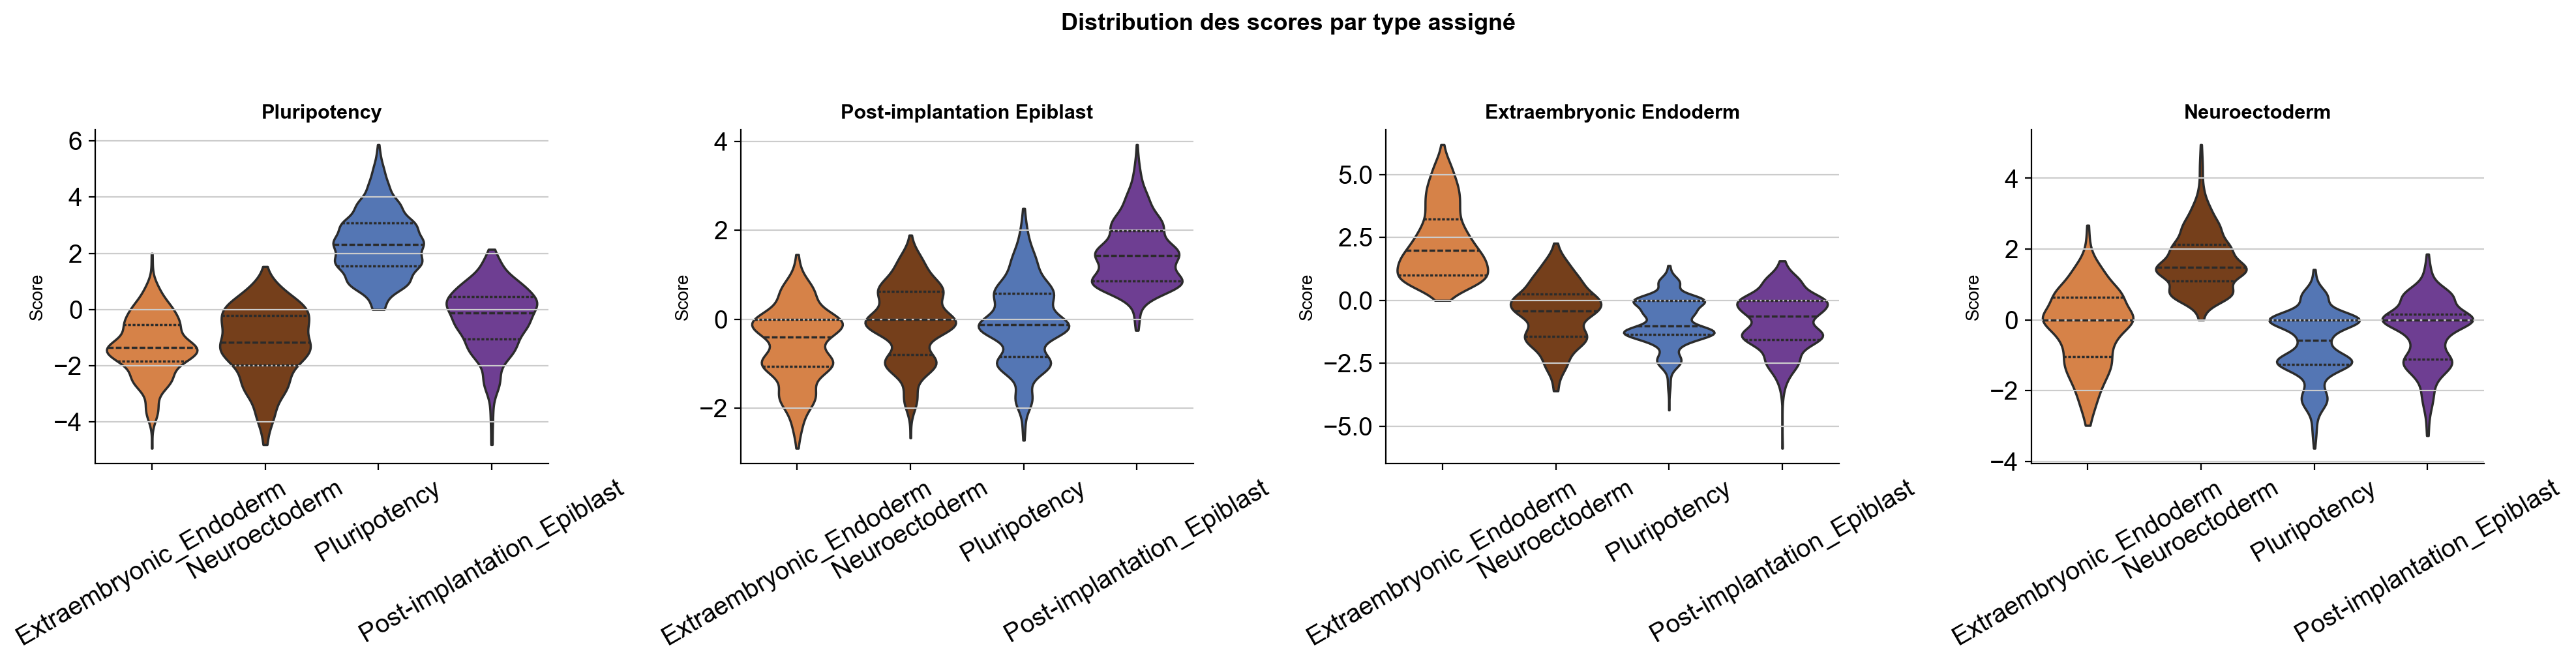

Figure sauvegardée : violin_scores.png


In [48]:
n_sigs = len(score_cols)
fig, axes = plt.subplots(1, n_sigs, figsize=(5 * n_sigs, 5), sharey=False)
if n_sigs == 1:
    axes = [axes]

for ax, col, sig in zip(axes, score_cols, sig_names):
    data_plot = adata.obs[[col, 'dominant_signature']].copy()
    data_plot.columns = ['score', 'type']
    order = sorted(data_plot['type'].unique())
    palette_local = {k: PALETTE.get(k, "#AAAAAA") for k in order}

    sns.violinplot(
        data=data_plot, x='type', y='score',
        palette=palette_local, order=order,
        cut=0, inner='quartile', ax=ax
    )
    ax.set_title(sig.replace("_", " "), fontsize=11, fontweight='bold')
    ax.set_xlabel("")
    ax.set_ylabel("Score", fontsize=10)
    ax.tick_params(axis='x', rotation=30)
    sns.despine(ax=ax)

plt.suptitle("Distribution des scores par type assigné", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("Figure sauvegardée : violin_scores.png")

### 8.5 UMAP coloré par score continu (une figure par signature)

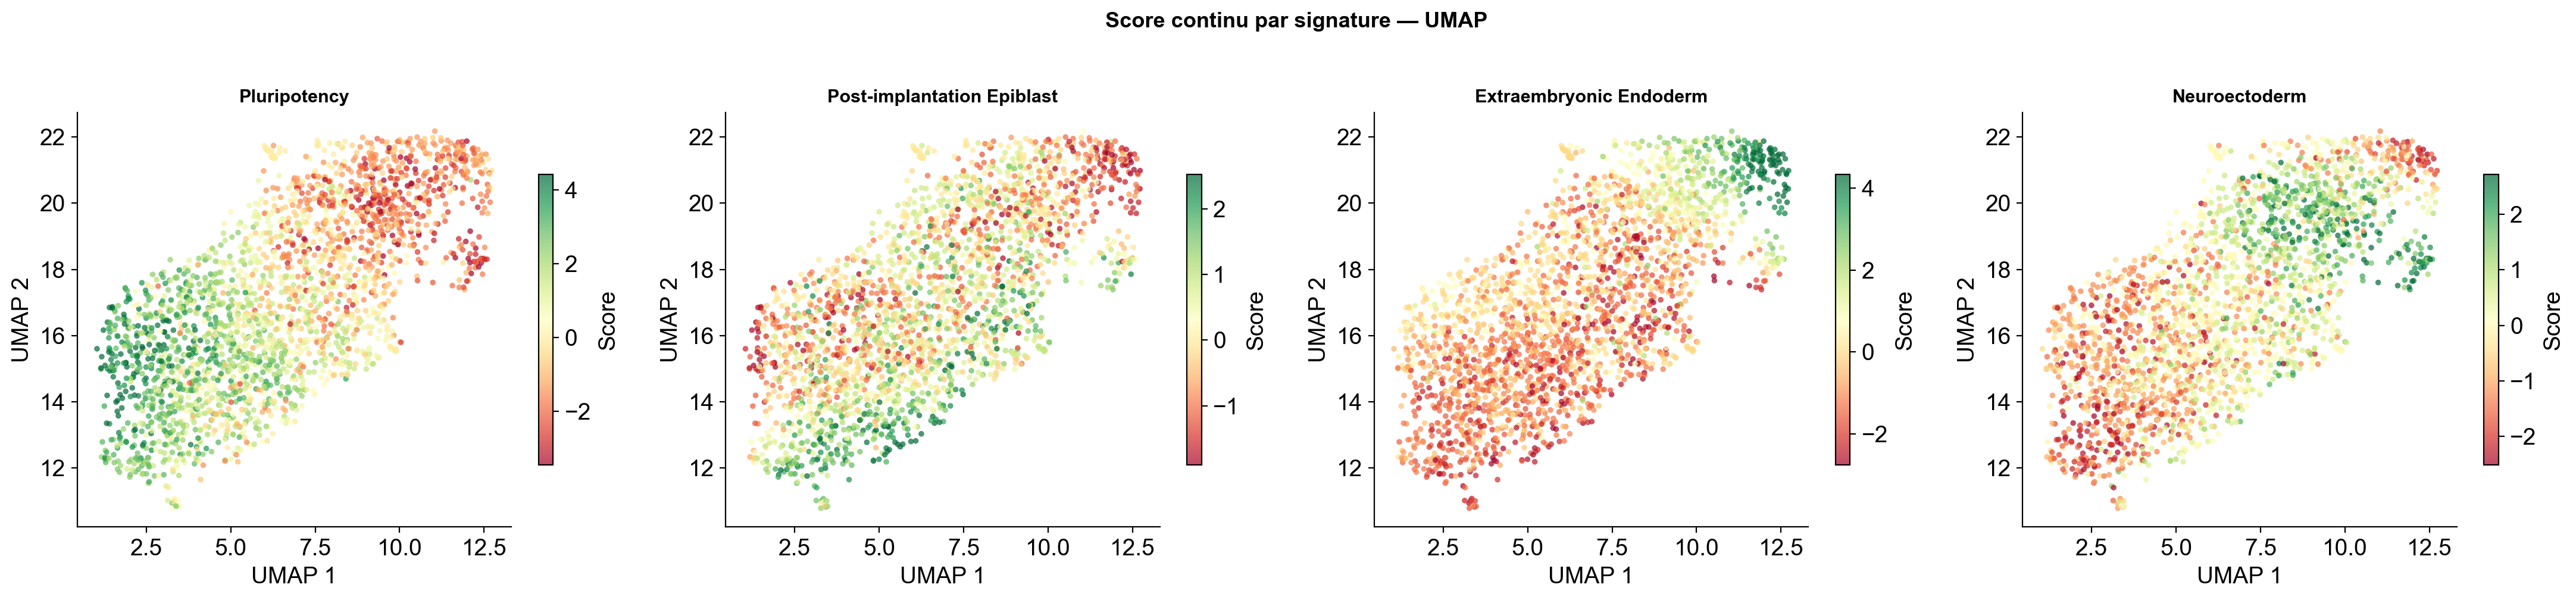

Figure sauvegardée : umap_continuous_scores.png


In [49]:
fig, axes = plt.subplots(1, n_sigs, figsize=(5.5 * n_sigs, 5))
if n_sigs == 1:
    axes = [axes]

for ax, col, sig in zip(axes, score_cols, sig_names):
    scores = adata.obs[col].values
    vmin, vmax = np.percentile(scores, [2, 98])

    sc_plot = ax.scatter(
        umap_coords[:, 0], umap_coords[:, 1],
        c=scores, cmap='RdYlGn', vmin=vmin, vmax=vmax,
        s=12, alpha=0.7, linewidths=0
    )
    plt.colorbar(sc_plot, ax=ax, shrink=0.7, label='Score')
    ax.set_title(sig.replace("_", " "), fontsize=11, fontweight='bold')
    ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
    ax.grid(False)
    sns.despine(ax=ax)

plt.suptitle("Score continu par signature — UMAP", fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print("Figure sauvegardée : umap_continuous_scores.png")

## 9. Clustering de Leiden (optionnel — confirmation des groupes)

In [50]:
# Clustering de Leiden sur le graphe des voisins calculé sur les gènes de signature
sc.tl.leiden(
    adata_sig,
    resolution=0.5,
    random_state=RANDOM_SEED,
    key_added='leiden_sig'
)
adata.obs['leiden_sig'] = adata_sig.obs['leiden_sig']

# Score moyen par cluster Leiden
cluster_score_df = adata.obs[score_cols + ['leiden_sig']].copy()
cluster_score_df.columns = [c.replace(prefix, '').replace('_', ' ') for c in score_cols] + ['Cluster']
cluster_means = cluster_score_df.groupby('Cluster').mean()
cluster_means['Dominant_Sig'] = cluster_means.idxmax(axis=1)

print("Score moyen par cluster Leiden :")
print(cluster_means)

# Assignation du type cellulaire au cluster
cluster_to_type = cluster_means['Dominant_Sig'].to_dict()
adata.obs['leiden_cell_type'] = adata.obs['leiden_sig'].map(cluster_to_type)
print("\nAssignation cluster → type cellulaire :")
print(cluster_to_type)

running Leiden clustering
    finished (0:00:00)
Score moyen par cluster Leiden :
         Pluripotency  Post-implantation Epiblast  Extraembryonic Endoderm  \
Cluster                                                                      
0            2.111413                    0.316804                -0.960336   
1           -1.242471                   -0.206337                 1.033918   
2           -0.021765                    0.445788                -0.965104   
3            0.993300                    0.292931                -0.077604   
4           -1.670468                    0.692273                -0.111272   
5           -0.131380                    0.142332                 0.034532   

         Neuroectoderm                Dominant_Sig  
Cluster                                             
0            -0.821137                Pluripotency  
1             0.526626     Extraembryonic Endoderm  
2             0.267416  Post-implantation Epiblast  
3            -0.269414      

/var/folders/lj/409601z9289fp_pv32k6f3frf4h14r/T/ipykernel_24993/3989823165.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_means = cluster_score_df.groupby('Cluster').mean()


## 10. Export des résultats

In [51]:
# Colonnes à exporter
export_cols = score_cols + ['dominant_signature', 'leiden_sig', 'leiden_cell_type']
export_cols = [c for c in export_cols if c in adata.obs.columns]

results_df = adata.obs[export_cols].copy()
results_df.to_csv('cell_signature_scores.csv')
print("Résultats exportés : cell_signature_scores.csv")
print(results_df.head(10))

# Sauvegarde de l'AnnData enrichi
print("\nAnnData sauvegardé : data_full_scored.h5ad")
print(f"Colonnes ajoutées dans adata.obs : {export_cols}")

Résultats exportés : cell_signature_scores.csv
   score_Pluripotency  score_Post-implantation_Epiblast  \
0            5.017789                         -0.851693   
1            0.311451                          1.453026   
2            4.532366                          0.357315   
3            0.731955                         -0.166167   
4            2.828370                         -0.830836   
5            4.384052                         -2.420788   
6            2.767432                         -0.299698   
7            3.633946                          0.000000   
8            3.124154                         -0.082729   
9            3.170710                         -0.942112   

   score_Extraembryonic_Endoderm  score_Neuroectoderm  \
0                      -1.135591            -1.135591   
1                       0.795793            -2.537176   
2                      -2.155202            -2.568904   
3                      -0.443113             0.000000   
4                 

## 11. Récapitulatif des signatures utilisées

| Type cellulaire | Gènes (réseau) |
|----------------|----------------|
| **Pluripotency** | Esrrb, Nr0b1, Dppa3, Pou5f1, Sox2, Jarid2, Zfp42, Klf4, Fgf4, Klf2 |
| **Post-implantation Epiblast** | Dppa2, Dnmt3a, Dnmt3b, Zic2, Zic3, Cer1, Fgf5, Wnt8a, Dppa4, Pou3f1 |
| **Extraembryonic Endoderm** | Fst, Pdgfra, Gata4, Gata6, Col4a2, Krt8, Sox17, Lamb1, Dab2 |
| **Neuroectoderm** | Sox1, Sox11, Meis1, Nes, Ascl1, Pax6, Sox9, Cd24a, Cdh2, Hoxb2, Hoxa1 |

> **Gènes hub (gris dans le réseau, exclus des signatures) :** RA, Sparc  
> Ces nœuds sont des régulateurs multi-signatures et n'ont pas été attribués à un type cellulaire unique.